In [1]:
import numpy as np
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
vectorizer = TfidfVectorizer()

df = pd.read_csv("../data/quran.csv")

cols = list(df.columns)
cols[0] = 'chapter#' 
cols[1] = 'verse#'
cols[2] = 'd_verse'
cols[3] = 'verse'
cols[9] = 'd_chapter'
cols[10] = 'chapter'
df.columns = cols
df = df.sort_values(by=['chapter#','verse#']).reset_index(drop=True)
df.drop([6459], axis=0, inplace=True)

In [3]:
df.head(50)

,chapter#,verse#,d_verse,verse,22b81fd12c136d4cf67a37de941908d83eaf8e97571c4983f9308d30d52ad8f9,0.25,1.1,١,1.2,d_chapter,chapter,1.3,0.1
0,1,1,بِسۡمِ ٱللَّهِ ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ,بسم الله الرحمٰن الرحيم,803dee27b5a9ddf866112eac2f8a34e5bd83ca08015ec4...,0.25,1,١,2,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
1,1,2,ٱلۡحَمۡدُ لِلَّهِ رَبِّ ٱلۡعَٰلَمِينَ,الحمد لله رب العٰلمين,ef2e84a7a99f9340845888a735cf6950853f9e1a13cff3...,0.25,1,١,3,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
2,1,3,ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ,الرحمٰن الرحيم,fa43107ca02d890e5115053aed9835bfbefb79ffa68464...,0.25,1,١,4,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
3,1,4,مَٰلِكِ يَوۡمِ ٱلدِّينِ,مٰلك يوم الدين,4355fb3e57b0b8b4e47545d28d30b98359fea1a18e5bfc...,0.25,1,١,5,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
4,1,5,إِيَّاكَ نَعۡبُدُ وَإِيَّاكَ نَسۡتَعِينُ,اياك نعبد واياك نستعين,8fc4ad4ff4e86be9abf8b5c66fd47a316b760844456c87...,0.25,1,١,6,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
5,1,6,ٱهۡدِنَا ٱلصِّرَٰطَ ٱلۡمُسۡتَقِيمَ,اهدنا الصرٰط المستقيم,3588b00e5f634a98aad43530808b52caa9b481dad46dda...,0.25,1,١,7,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
6,1,7,صِرَٰطَ ٱلَّذِينَ أَنۡعَمۡتَ عَلَيۡهِمۡ غَيۡرِ...,صرٰط الذين انعمت عليهم غير المغضوب عليهم ولا ا...,2a2c9b6be73c32c7956511168c280f11d1d7c45d877574...,0.25,1,١,8,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0
7,2,0,سُورَةُ البَقَرَةِ,سورة البقرة,b9646eafdec422426ae5fbe958306ee6b0a4471328a4f6...,0.25,2,٢,9,سُورَةُ البَقَرَةِ,سورة البقرة,1,0
8,2,0,بِسۡمِ ٱللَّهِ ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ,بسم الله الرحمٰن الرحيم,803dee27b5a9ddf866112eac2f8a34e5bd83ca08015ec4...,0.25,2,٢,10,سُورَةُ البَقَرَةِ,سورة البقرة,1,0
9,2,1,الٓمٓ,الم,49c5355bd921dc0d810e3be457432004847a72d5dbe754...,0.25,2,٢,11,سُورَةُ البَقَرَةِ,سورة البقرة,1,0


In [ ]:

from scipy.cluster.hierarchy import dendrogram, fcluster

vectorized_verses = vectorizer.fit_transform(df['verse'])

# Run agglomerative clustering algorithm on verses
hc = AgglomerativeClustering(
    n_clusters=None,
    metric="cosine",
    linkage="complete",
    distance_threshold=0,
    compute_distances=True
)
y = hc.fit_predict(vectorized_verses.toarray())

def sklearn_model_to_linkage(model):
    counts = np.zeros(model.children_.shape[0]) #Model.children is a 2D array that keeps track of all of the merges
    n_samples = len(model.labels_) #An array same size as number of verses

    for i, merge in enumerate(model.children_):
        count = 0
        for child_idx in merge:
            if child_idx < n_samples: 
                count += 1
            else:
                count += counts[child_idx - n_samples]
        counts[i] = count

    # columns: child1, child2, distance, sample_count
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)
    return linkage_matrix

# Create linkage matrix and save as array. Also save cleaned and sorted dataframe of verses as csv
Z = sklearn_model_to_linkage(hc)

np.save("../data/hc_linkage.npy", Z)
df[["chapter#", "verse#", "chapter", "verse"]].to_csv(
    "../data/hc_verses.csv", index=False
)

cluster size: 116 fig is None: False
Cluster 8 has 116 verses.
[   0    2    8  295  498  676  798  965 1173 1380] 116


C:\Users\zainz\AppData\Local\Temp\ipykernel_46056\1399733745.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


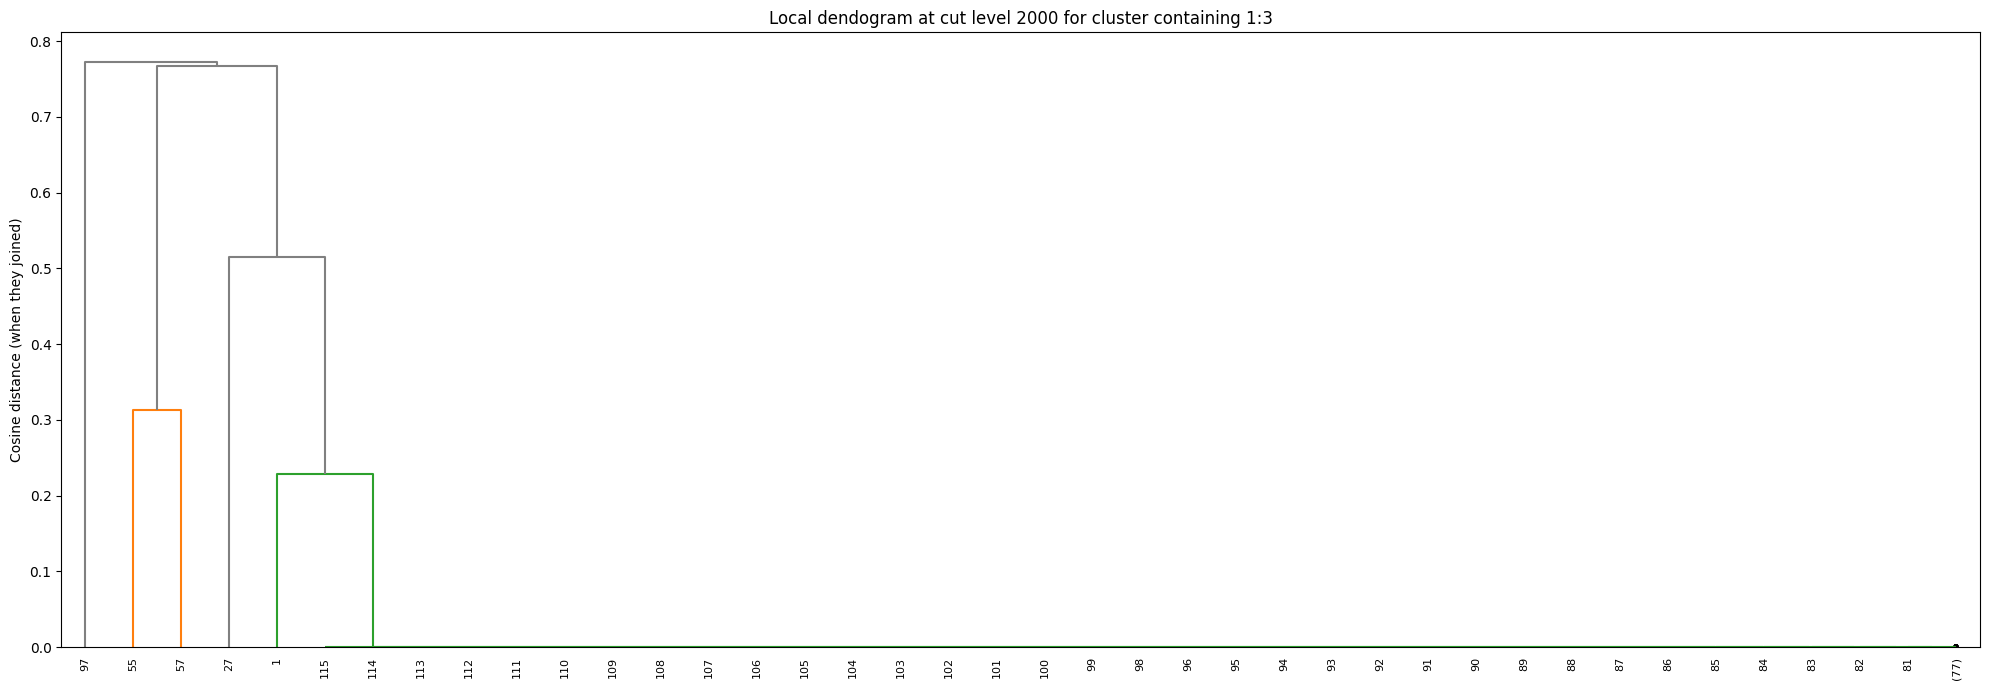

In [ ]:
#Build local dendrogram
import os
import sys
import importlib

sys.path.append(os.path.abspath(".."))  # add project root
import utils
importlib.reload(utils)
from utils import build_local_dendrogram

result = build_local_dendrogram(
    1, 3, Z, k=2000, vectorized_verses=vectorized_verses, df=df
)

# Support both older (fig, member_idx) and newer (fig, member_idx, msg) returns
if len(result) == 3:
    fig, member_idx, msg = result
else:
    fig, member_idx = result
    msg = "No message returned (older function version)."

print("cluster size:", len(member_idx), "fig is None:", fig is None)
print(msg)
if fig is not None:
    fig.show()
print(member_idx[:10], len(member_idx))